In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Load the dataset

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# EDA (Exploratory Data Analysis)

In [4]:
print("Number of rows and columns:", df.shape)

Number of rows and columns: (7043, 21)


In [5]:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [7]:
#Check Missing Values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
# Check for duplicate rows
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
7038    False
7039    False
7040    False
7041    False
7042    False
Length: 7043, dtype: bool

In [9]:
# Understand Numerical Variables
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [10]:
# Understand categorical variables.
df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [11]:
# Check for missing values in TotalCharges column
(df["TotalCharges"].astype(str).str.strip() == "").sum()

np.int64(11)

In [12]:
# Display customers with blank TotalCharges

df[df["TotalCharges"].astype(str).str.strip() == ""][
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [13]:
# Convert TotalCharges from string to numeric
# Blank values will become NaN

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [14]:
# Check missing TotalCharges values

df["TotalCharges"].isnull().sum()

np.int64(11)

In [15]:
# Display customers with missing TotalCharges

df[df["TotalCharges"].isnull()][
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


In [35]:
# Replace missing TotalCharges with 0
# These customers have 0 months of tenure

df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

In [36]:
# Verify TotalCharges has no missing values

df["TotalCharges"].isnull().sum()

np.int64(0)

In [37]:
df["TotalCharges"].dtype

dtype('float64')

In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7043 non-null   str     
 1   gender            7043 non-null   str     
 2   SeniorCitizen     7043 non-null   int64   
 3   Partner           7043 non-null   str     
 4   Dependents        7043 non-null   str     
 5   tenure            7043 non-null   int64   
 6   PhoneService      7043 non-null   str     
 7   MultipleLines     7043 non-null   str     
 8   InternetService   7043 non-null   str     
 9   OnlineSecurity    7043 non-null   str     
 10  OnlineBackup      7043 non-null   str     
 11  DeviceProtection  7043 non-null   str     
 12  TechSupport       7043 non-null   str     
 13  StreamingTV       7043 non-null   str     
 14  StreamingMovies   7043 non-null   str     
 15  Contract          7043 non-null   str     
 16  PaperlessBilling  7043 non-null   s

In [39]:
# Churn summary table

churn_summary = df["Churn"].value_counts().to_frame("Count")

churn_summary["Percentage"] = (
    df["Churn"].value_counts(normalize=True) * 100
).round(2)

churn_summary

,Count,Percentage
Churn,,
No,5174,73.46
Yes,1869,26.54


In [40]:
# Churn percentage by contract type

contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn.round(2)

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


In [22]:
# Customer count by contract type and churn

pd.crosstab(
    df["Contract"],
    df["Churn"]
)

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


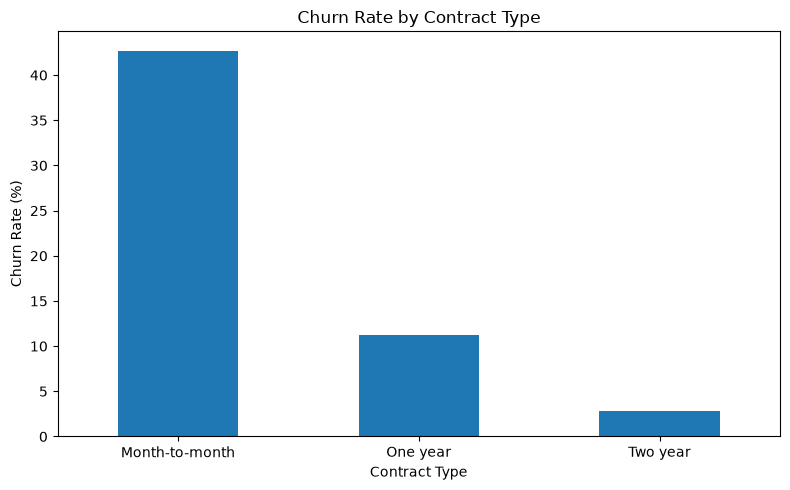

In [23]:
# Chart 1: Churn rate by contract type

contract_churn["Yes"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("churn_by_contract.png", dpi=300)
plt.show()

In [24]:
# Churn percentage by Internet Service

internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

internet_churn.round(2)

Churn,No,Yes
InternetService,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


In [25]:
# Customer count by Internet Service and Churn

pd.crosstab(
    df["InternetService"],
    df["Churn"]
)

Churn,No,Yes
InternetService,,
DSL,1962,459
Fiber optic,1799,1297
No,1413,113


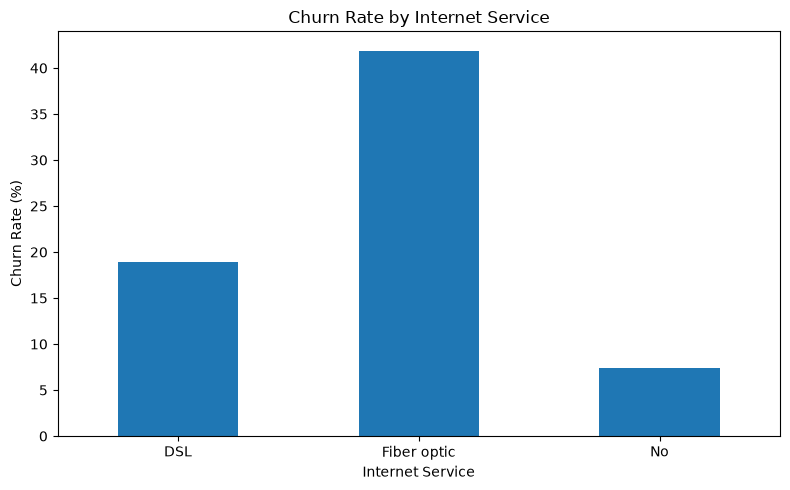

In [26]:
# Chart 2: Churn rate by Internet Service

internet_churn["Yes"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("churn_by_internet_service.png", dpi=300)
plt.show()

In [27]:
# Average tenure by churn status

df.groupby("Churn")["tenure"].mean().round(2)

Churn
No     37.57
Yes    17.98
Name: tenure, dtype: float64

In [28]:
# Create customer tenure groups

df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=[
        "0-12 months",
        "13-24 months",
        "25-48 months",
        "49-72 months"
    ]
)

In [29]:
# Churn percentage by tenure group

tenure_churn = pd.crosstab(
    df["tenure_group"],
    df["Churn"],
    normalize="index"
) * 100

tenure_churn.round(2)

Churn,No,Yes
tenure_group,,
0-12 months,52.56,47.44
13-24 months,71.29,28.71
25-48 months,79.61,20.39
49-72 months,90.49,9.51


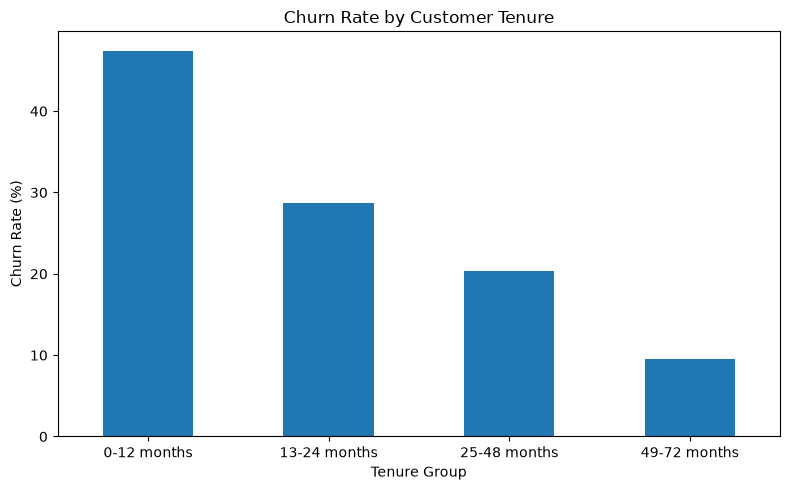

In [30]:
# Chart 3: Churn rate by customer tenure

tenure_churn["Yes"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("churn_by_tenure.png", dpi=300)
plt.show()

In [31]:
# Average monthly charges by churn status

df.groupby("Churn")["MonthlyCharges"].mean().round(2)

Churn
No     61.27
Yes    74.44
Name: MonthlyCharges, dtype: float64

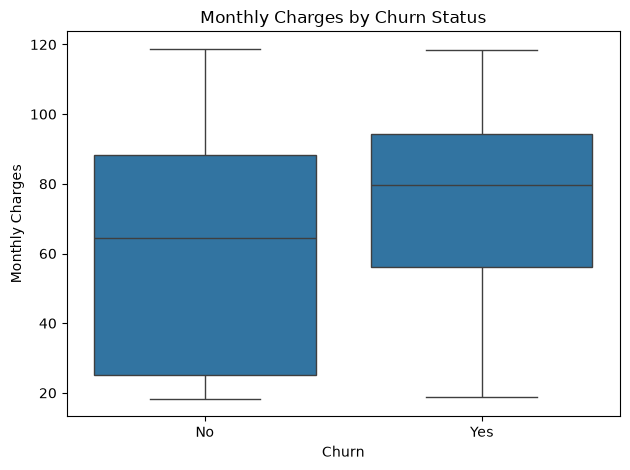

In [32]:
# Chart 4: Monthly Charges vs Churn

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.tight_layout()

plt.savefig("monthly_charges_by_churn.png", dpi=300)
plt.show()

In [33]:
""" #Insights

1. Overall Customer Churn

The overall customer churn rate is **26.54%**, with 1,869 out of 7,043 customers having churned. This indicates that customer retention is a significant business challenge. The company should focus on identifying high-risk customers early and introducing targeted retention strategies.

2. Contract Type Has a Strong Relationship with Churn

Month-to-month customers have a substantially higher churn rate than customers on one-year or two-year contracts. This suggests that customers with shorter commitments are more likely to leave. The company could encourage longer-term contracts through discounts, loyalty benefits, or other incentives.

3. Fiber Optic Customers Show Higher Churn

Customers using **Fiber optic** internet service show a considerably higher churn rate than customers using DSL or customers without internet service. This indicates that the company should investigate pricing, service quality, customer support, and customer expectations associated with Fiber optic plans.

4. Newer Customers Are More Likely to Churn

Customers with shorter tenure have a much higher churn rate. The churn rate is highest among customers with **0–12 months of tenure** and decreases as customer tenure increases. This suggests that the early customer lifecycle is a critical period for retention, and improved onboarding and early engagement could help reduce churn.

5. Higher Monthly Charges Are Associated with Higher Churn

Customers who churn tend to have higher monthly charges than customers who remain with the company. This suggests that pricing or perceived value may contribute to customer churn. The company should review pricing and consider targeted offers for high-charge customers who are at risk of leaving."""

' #Insights\n\n1. Overall Customer Churn\n\nThe overall customer churn rate is **26.54%**, with 1,869 out of 7,043 customers having churned. This indicates that customer retention is a significant business challenge. The company should focus on identifying high-risk customers early and introducing targeted retention strategies.\n\n2. Contract Type Has a Strong Relationship with Churn\n\nMonth-to-month customers have a substantially higher churn rate than customers on one-year or two-year contracts. This suggests that customers with shorter commitments are more likely to leave. The company could encourage longer-term contracts through discounts, loyalty benefits, or other incentives.\n\n3. Fiber Optic Customers Show Higher Churn\n\nCustomers using **Fiber optic** internet service show a considerably higher churn rate than customers using DSL or customers without internet service. This indicates that the company should investigate pricing, service quality, customer support, and customer 

In [41]:
# Drop customerID column as it is not useful for analysis
df = df.drop('customerID', axis=1)


In [42]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn', 'tenure_group'],
      dtype='str')

In [43]:
df.shape

(7043, 21)

In [44]:
# Convert Churn column to binary values
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [45]:
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [46]:
df['Churn'].unique()

array([0, 1])

In [47]:
# Separate features (X) and target (y)

X = df.drop('Churn', axis=1)
y = df['Churn']

In [48]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 20)
y shape: (7043,)


In [49]:
# Identify numerical columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

num_cols

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

In [50]:
# Identify categorical columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

cat_cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'tenure_group']

In [51]:
print("Numerical columns:", num_cols)
print("\nCategorical columns:", cat_cols)

print("\nNumber of numerical columns:", len(num_cols))
print("Number of categorical columns:", len(cat_cols))

Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group']

Number of numerical columns: 4
Number of categorical columns: 16


In [54]:
# Create a new engineered feature
df['monthly_per_tenure'] = df['MonthlyCharges'] / (df['tenure'] + 1)

In [55]:
# Add the new feature to X
X = df.drop('Churn', axis=1)

In [56]:
print("X shape:", X.shape)
print("New feature value:")
print(X[['MonthlyCharges', 'tenure', 'monthly_per_tenure']].head())

X shape: (7043, 21)
New feature value:
   MonthlyCharges  tenure  monthly_per_tenure
0           29.85       1           14.925000
1           56.95      34            1.627143
2           53.85       2           17.950000
3           42.30      45            0.919565
4           70.70       2           23.566667


In [57]:
from sklearn.model_selection import train_test_split

# Recreate train-test split after feature engineering
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [58]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5634, 21)
X_test shape: (1409, 21)
y_train shape: (5634,)
y_test shape: (1409,)


In [60]:
# Re-identify numerical and categorical columns
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numerical columns:", num_cols)
print("\nCategorical columns:", cat_cols)
print("\nNumber of numerical columns:", len(num_cols))
print("Number of categorical columns:", len(cat_cols))

Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'monthly_per_tenure']

Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group']

Number of numerical columns: 5
Number of categorical columns: 16


In [61]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [62]:
# Create preprocessing transformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

In [64]:
('num', StandardScaler(), num_cols)

('num',
 StandardScaler(),
 ['SeniorCitizen',
  'tenure',
  'MonthlyCharges',
  'TotalCharges',
  'monthly_per_tenure'])

In [65]:
('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)

('cat',
 OneHotEncoder(handle_unknown='ignore'),
 ['gender',
  'Partner',
  'Dependents',
  'PhoneService',
  'MultipleLines',
  'InternetService',
  'OnlineSecurity',
  'OnlineBackup',
  'DeviceProtection',
  'TechSupport',
  'StreamingTV',
  'StreamingMovies',
  'Contract',
  'PaperlessBilling',
  'PaymentMethod',
  'tenure_group'])

In [66]:
print(preprocessor)

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['SeniorCitizen', 'tenure', 'MonthlyCharges',
                                  'TotalCharges', 'monthly_per_tenure']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['gender', 'Partner', 'Dependents',
                                  'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'Contract',
                                  'PaperlessBilling', 'PaymentMethod',
                                  'tenure_group'])])


In [67]:
# Fit the preprocessor on training data
X_train_processed = preprocessor.fit_transform(X_train)

In [68]:
# Transform test data using the fitted preprocessor
X_test_processed = preprocessor.transform(X_test)

In [69]:
print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape:", X_test_processed.shape)

Processed X_train shape: (5634, 50)
Processed X_test shape: (1409, 50)


In [70]:
print(type(X_train_processed))
print(type(X_test_processed))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [71]:
import numpy as np

print("NaN values in X_train:", np.isnan(X_train_processed).sum())
print("NaN values in X_test:", np.isnan(X_test_processed).sum())

print("Infinite values in X_train:", np.isinf(X_train_processed).sum())
print("Infinite values in X_test:", np.isinf(X_test_processed).sum())

NaN values in X_train: 0
NaN values in X_test: 0
Infinite values in X_train: 0
Infinite values in X_test: 0


In [79]:
import os

# Get the full path
models_path = os.path.join(os.getcwd(), "models")

print("Models path:")
print(models_path)

print("\nBefore creating folder:")
print("Exists:", os.path.exists(models_path))
print("Is directory:", os.path.isdir(models_path))

# Create the folder if necessary
os.makedirs(models_path, exist_ok=True)

print("\nAfter creating folder:")
print("Exists:", os.path.exists(models_path))
print("Is directory:", os.path.isdir(models_path))

Models path:
d:\Churn_Analysis\models

Before creating folder:
Exists: False
Is directory: False

After creating folder:
Exists: True
Is directory: True


In [80]:
test_file = os.path.join(models_path, "test.txt")

with open(test_file, "w") as f:
    f.write("Test successful")

print("Test file created successfully!")
print(test_file)

Test file created successfully!
d:\Churn_Analysis\models\test.txt


In [81]:
import joblib

# Save the fitted preprocessor
preprocessor_file = os.path.join(models_path, "preprocessor.pkl")

joblib.dump(preprocessor, preprocessor_file)

print("Preprocessor saved successfully!")
print(preprocessor_file)

Preprocessor saved successfully!
d:\Churn_Analysis\models\preprocessor.pkl


In [82]:
# Save processed training and testing data

joblib.dump(X_train_processed, os.path.join(models_path, "X_train_processed.pkl"))
joblib.dump(X_test_processed, os.path.join(models_path, "X_test_processed.pkl"))
joblib.dump(y_train, os.path.join(models_path, "y_train.pkl"))
joblib.dump(y_test, os.path.join(models_path, "y_test.pkl"))

print("All processed data saved successfully!")

All processed data saved successfully!


In [83]:
print("Files in models folder:")

for file in os.listdir(models_path):
    print(file)

Files in models folder:
preprocessor.pkl
test.txt
X_test_processed.pkl
X_train_processed.pkl
y_test.pkl
y_train.pkl


In [ ]:
# Insights 

"""Customer ID was removed because it is only an identifier and does not provide useful information for predicting churn.

   The target variable Churn was converted into binary values — Yes = 1 and No = 0 — so it can be used for machine-learning
   classification.

   The dataset was divided into 80% training and 20% testing data using stratification, maintaining the churn distribution in both
   sets.

   Feature engineering was performed by creating monthly_per_tenure, which provides an additional derived feature from MonthlyCharges
   and tenure. The existing tenure_group feature was also retained.

   Data was prepared for ML models using a ColumnTransformer — numerical features were standardized using StandardScaler, 
   while categoricalfeatures were converted using OneHotEncoder. After preprocessing, the data increased from 21 features 
   to 50 features, with no NaN or infinite values."""